Task 2: Measure Overlap Intensity

Step 1: For each patent count the number of focal terms

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_parquet("output_dataset/focal_terms.parquet")

num_focal_terms_per_patent = (
    df.groupby("patent_id")["focal_term"]
      .nunique()
      .reset_index(name="num_focal_terms")
)

num_focal_terms_per_patent.head()

,patent_id,num_focal_terms
0,7662783,16
1,7700783,2
2,7704363,4
3,7723513,11
4,7741269,4


In [2]:
df["focal_term"].nunique()

494

In [3]:
import pandas as pd

df_focal = pd.read_parquet("output_dataset/focal_terms.parquet")
df_link  = pd.read_parquet("SampleGloria_Link_PmidOa.parquet")

print("Unique focal terms:", df_focal["focal_term"].nunique())
print("Unique patents:    ", df_focal["patent_id"].nunique())
print("Unique PMIDs:      ", df_link["pmid"].nunique())

Unique focal terms: 494
Unique patents:     101
Unique PMIDs:       3745


Step 2 Compute the distribution across patents:

    mean
    median
    standard deviation
    min / max
    histogram or density plot


In [4]:
print("=== Overall counts ===")
print(f"Total (patent_id, focal_term) pairs : {len(df_focal)}")
print(f"Unique patents                       : {df_focal['patent_id'].nunique()}")
print(f"Unique focal term strings            : {df_focal['focal_term'].nunique()}")
print()
print("=== Distribution of focal terms per patent ===")
stats = num_focal_terms_per_patent["num_focal_terms"].describe()
print(stats)
print(f"\nVerification: 101 patents × mean {stats['mean']:.4f} ≈ {101 * stats['mean']:.0f} pairs (should be 790)")

=== Overall counts ===
Total (patent_id, focal_term) pairs : 790
Unique patents                       : 101
Unique focal term strings            : 494

=== Distribution of focal terms per patent ===
count    101.000000
mean       7.821782
std        6.832856
min        1.000000
25%        3.000000
50%        6.000000
75%       11.000000
max       30.000000
Name: num_focal_terms, dtype: float64

Verification: 101 patents × mean 7.8218 ≈ 790 pairs (should be 790)


Visualizations

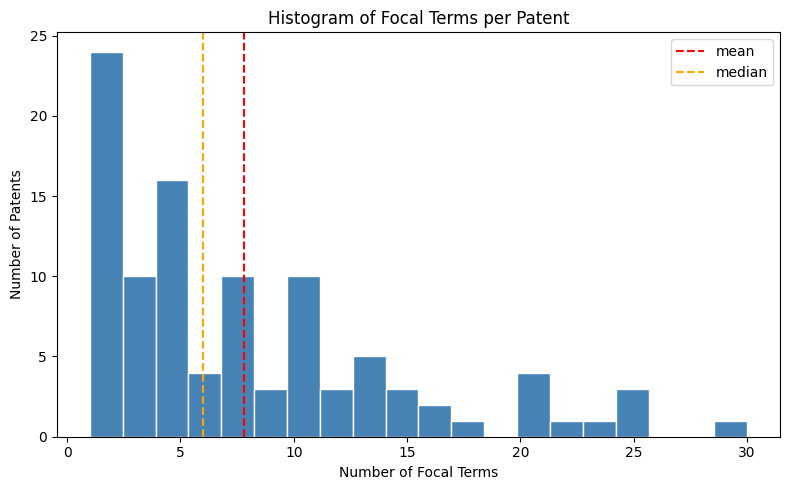

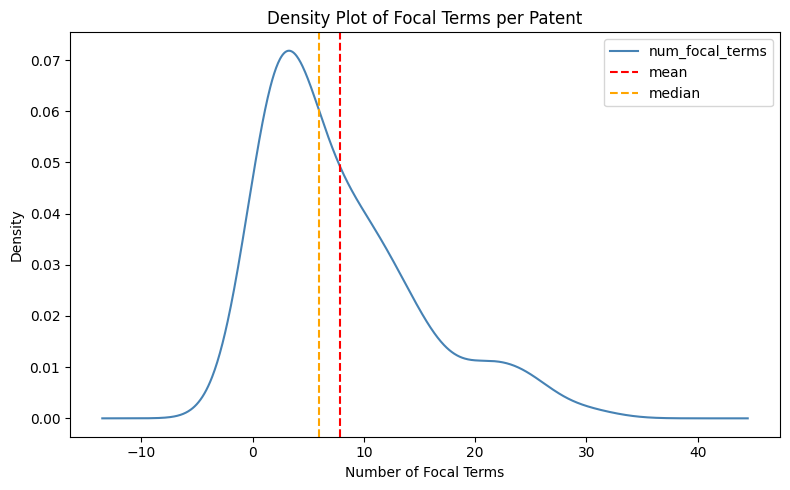

In [5]:
# Histogram
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(num_focal_terms_per_patent["num_focal_terms"], bins=20, color="steelblue", edgecolor="white")
ax.set_title("Histogram of Focal Terms per Patent")
ax.set_xlabel("Number of Focal Terms")
ax.set_ylabel("Number of Patents")
ax.axvline(num_focal_terms_per_patent["num_focal_terms"].mean(), color="red", linestyle="--", label="mean")
ax.axvline(num_focal_terms_per_patent["num_focal_terms"].median(), color="orange", linestyle="--", label="median")
ax.legend()
plt.tight_layout()
plt.savefig("visualizations/histogram_focal_terms.png", dpi=150)
plt.show()

# Density plot
fig, ax = plt.subplots(figsize=(8, 5))
num_focal_terms_per_patent["num_focal_terms"].plot.kde(ax=ax, color="steelblue")
ax.set_title("Density Plot of Focal Terms per Patent")
ax.set_xlabel("Number of Focal Terms")
ax.set_ylabel("Density")
ax.axvline(num_focal_terms_per_patent["num_focal_terms"].mean(), color="red", linestyle="--", label="mean")
ax.axvline(num_focal_terms_per_patent["num_focal_terms"].median(), color="orange", linestyle="--", label="median")
ax.legend()
plt.tight_layout()
plt.savefig("visualizations/density_focal_terms.png", dpi=150)
plt.show()

## Deliverable: Task 2 — Measure Overlap Intensity

### Summary Statistics

| Statistic | Value |
|-----------|-------|
| Total (patent_id, focal_term) pairs | 790 |
| Unique patents | 101 |
| Unique focal term strings | 494 |
| Mean focal terms per patent | 7.82 |
| Median focal terms per patent | 6.00 |
| Std Dev | 6.83 |
| Min | 1 focal term |
| Max | 30 focal terms |

> Note: 790 pairs across 101 patents, but only 494 unique term strings — the same term (e.g. *"cell"*) can be a focal term in multiple patents.

---

### Distribution Plot
*(histogram and density plot saved in visualizations/focal_terms_distribution.png)*

---

### Interpretation

The 101 patents share on average **7.8 focal terms** with their cited scientific papers (median = 6),
totalling **790 unique (patent_id, focal_term) pairs**.
The distribution is **right-skewed**: most patents have few focal terms, but a small number have many.

Key observations:
- **25% of patents** have 3 or fewer focal terms → weak overlap with cited science
- **50% of patents** have 6 or fewer focal terms → moderate overlap
- **75% of patents** have 11 or fewer focal terms → only a minority shows strong overlap
- The high std (6.83 ≈ mean) confirms **high variability** across patents


  **Examples:**
- **17 patents** share only **1 focal term** (minimum), e.g. patent **7749408** which shares only the term *"room"*
  with its cited papers — very low terminological overlap
- Patent **7884261** with **6 focal terms** (median): shares terms *"increase"*, *"plant"*, 
  *"promoter"*, *"rice"*, *"transgenic"*, *"yield"* — a typical patent in the dataset, 
  suggesting moderate overlap with agricultural/biological science
- Patent **8280136** with **30 focal terms** (maximum): shares many terms including 
  *"cardiac"*, *"heart"*, *"dyssynchrony"*, *"myocardial"*, *"device"*, *"model"* — 
  strongly grounded in medical/cardiac scientific literature

In [6]:
# patent with minimum focal terms
print(num_focal_terms_per_patent[num_focal_terms_per_patent["num_focal_terms"] == 1])

# patent with median focal terms
print(num_focal_terms_per_patent[num_focal_terms_per_patent["num_focal_terms"] == 6])

# patent with maximum focal terms
print(num_focal_terms_per_patent[num_focal_terms_per_patent["num_focal_terms"] == 30])

   patent_id  num_focal_terms
5    7749408                1
8    7754909                1
14   7795285                1
23   7851841                1
32   7911465                1
36   7943608                1
46   7996241                1
51   8045718                1
53   8069102                1
61   8112375                1
66   8134025                1
75   8187835                1
87   8252319                1
88   8272844                1
91   8289159                1
92   8293340                1
96   8306179                1
   patent_id  num_focal_terms
27   7884261                6
33   7919314                6
59   8093262                6
84   8241282                6
   patent_id  num_focal_terms
90   8280136               30


In [7]:
# if patent_id is string
print(df[df["patent_id"] == "7749408"]["focal_term"].tolist())
print(df[df["patent_id"] == "7884261"]["focal_term"].tolist())
print(df[df["patent_id"] == "8280136"]["focal_term"].tolist())


['room']
['increase', 'plant', 'promoter', 'rice', 'transgenic', 'yield']
['and', 'anterior', 'anteroseptal', 'avoid', 'cardiac', 'class', 'consecutive', 'device', 'different', 'dyssynchrony', 'gradient', 'heart', 'image', 'implantation', 'information', 'initialization', 'intraventricular', 'location', 'method', 'model', 'myocardial', 'normal', 'optimal', 'placement', 'processing', 'range', 'region', 'shape', 'time', 'with']


In [8]:
df_pat = pd.read_parquet("SampleGloria_Pat_GlinerLabels.parquet")
print(df_pat["label"].value_counts())

label
Functional Concept      2973
Spatial Concept         2659
Quantitative Concept    2302
Chemical                1517
Activity                1284
                        ... 
Fish                       1
Vertebrate                 1
Neoplastic Process         1
Pathologic Function        1
Educational Activity       1
Name: count, Length: 115, dtype: int64
